In [1]:
import matplotlib.pyplot as plt
import numpy as np
from model_ranking.utils import load_h5, get_roi_slice

INFO: P [MainThread] 2026-08-08 08:17:06,273 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# EPFL

In [108]:
E_raw_data_path = "/g/kreshuk/talks/data/EPFL/resized_pixels/test.h5"

In [109]:
E_raw = load_h5(E_raw_data_path, "raw")
E_gt = load_h5(E_raw_data_path, "labels")
print(E_raw.shape, E_gt.shape)

(125, 480, 640) (125, 480, 640)


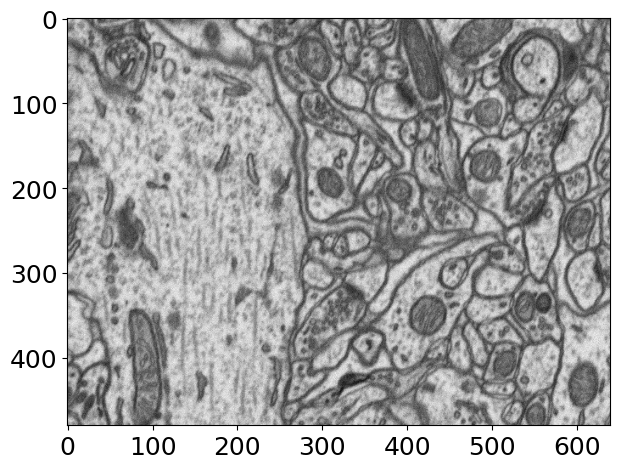

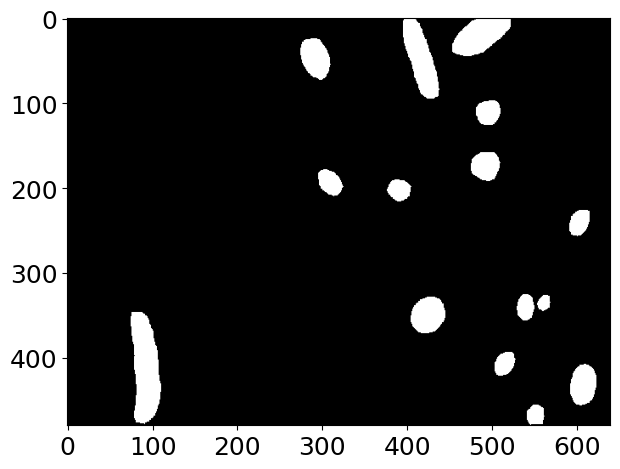

In [148]:
slice_id = 60

tick_fontsize = 18

_ = plt.imshow(E_raw[slice_id].squeeze(), cmap='gray')
#_ = plt.axis("off")
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/EPFL_raw.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(E_gt[slice_id].squeeze(), cmap='gray')
#_ = plt.axis("off")
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/EPFL_label.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

# Hmito

In [135]:
Hm_raw_data_path = "/g/kreshuk/talks/data/Hmito/test_converted.h5"

In [136]:
Hm_raw = load_h5(Hm_raw_data_path, "raw")
Hm_gt = load_h5(Hm_raw_data_path, "labels")
print(Hm_raw.shape)

(150, 4096, 4096)


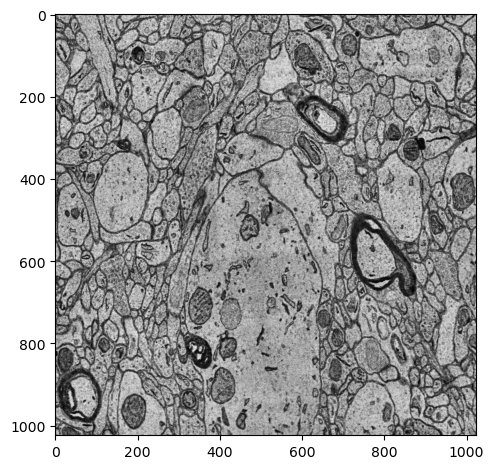

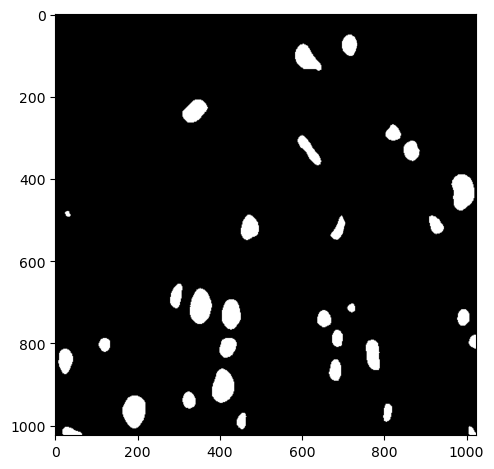

In [ ]:
# slice_id = [50, 100:580, :640]

tick_fontsize = 14

_ = plt.imshow(Hm_raw[50, 0:1024, 0:1024].squeeze(), cmap='gray')
#_ = plt.axis("off")
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/Hmito_raw_full.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(Hm_gt[50, 0:1024, 0:1024].squeeze(), cmap='gray')
#_ = plt.axis("off")
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/Hmito_label_full.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

### HmtoE U-Net Prediction

In [115]:
import torch
from pytorch3dunet.unet3d.model import get_model
from pytorch3dunet.unet3d.utils import load_checkpoint
from pytorch3dunet.augment.transforms import Normalize
from pytorch3dunet.unet3d.metrics import F1Score

In [116]:
ckpt_path = "/g/kreshuk/talks/segmentation_ModelSelection/experiments/Hmito/BatchNorm/Hm_model4/best_checkpoint.pytorch"
model_cfg = {
    "name": "UNet2D",
    "in_channels": 1,
    "out_channels": 1,
    "layer_order": "bcr",
    "f_maps": 32,
    "final_sigmoid": True,
    "feature_return": False,
    "is_segmentation": True,
    "feature_perturbation": None,
}
Hm_model = get_model(model_cfg)
load_checkpoint(ckpt_path, Hm_model)
Hm_model = Hm_model.cuda()

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [117]:
E_input = Normalize()(E_raw[None, None, 60])
E_input = torch.from_numpy(E_input).cuda()



In [118]:
Hm_model.eval()
with torch.no_grad():
    #E_input = torch.from_numpy(Hm_raw[None, None, 50, :1024, :1024]).float().cuda()
    HmtoE_pred = Hm_model(E_input).cpu().numpy()
print(HmtoE_pred.shape)



(1, 1, 480, 640)


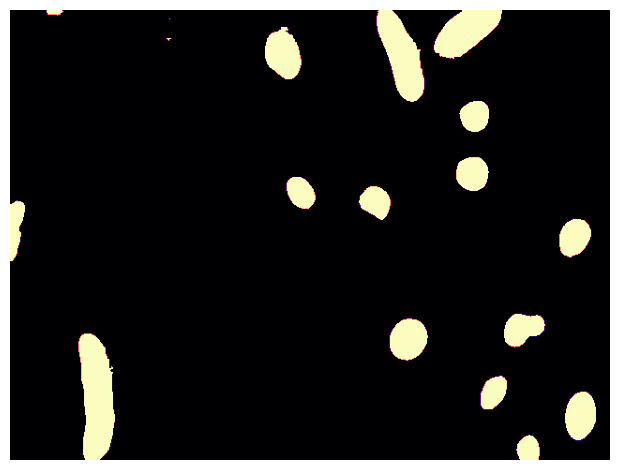

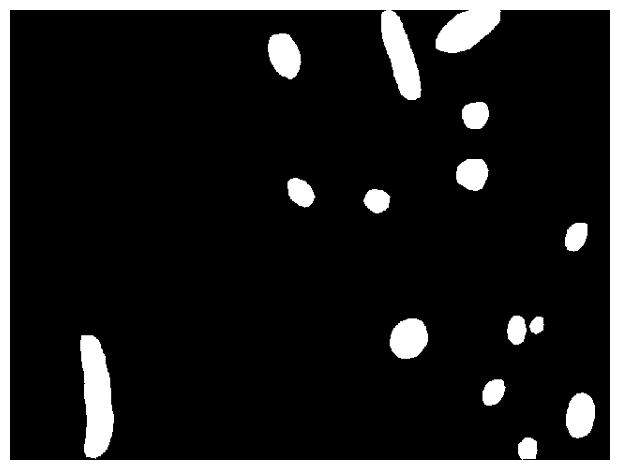

In [132]:
HmtoE_pred_th = HmtoE_pred > 0.5
HmtoE_f1 = F1Score(threshold=0.5)(torch.from_numpy(E_gt[60]).unsqueeze(0), torch.from_numpy(HmtoE_pred_th).unsqueeze(0))
_ = plt.imshow(HmtoE_pred_th.squeeze(), cmap='magma')
_ = plt.axis("off")
#plt.title(f"Hmito to EPFL (F1-score = {HmtoE_f1:.2f})")
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/raw_data/HmtoE_pred.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(E_gt[60].squeeze(), cmap='gray')
_ = plt.axis("off")
plt.tight_layout()
# plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/EPFL_label.png", bbox_inches="tight", pad_inches=0)
plt.show()

# Rmito

In [138]:
Rm_raw_data_path = "/g/kreshuk/talks/data/Rmito/test_converted.h5"

In [139]:
Rm_raw = load_h5(Rm_raw_data_path, "raw")
Rm_gt = load_h5(Rm_raw_data_path, "labels")
print(Rm_raw.shape)

(150, 4096, 4096)


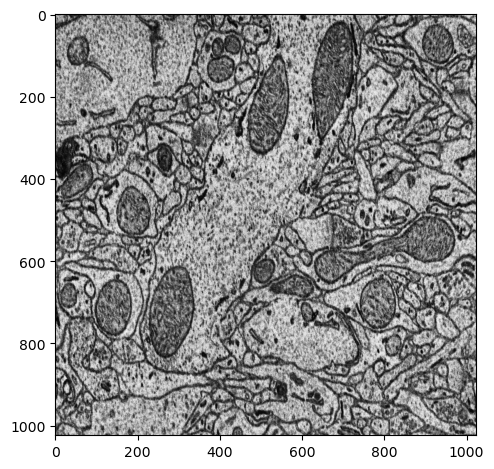

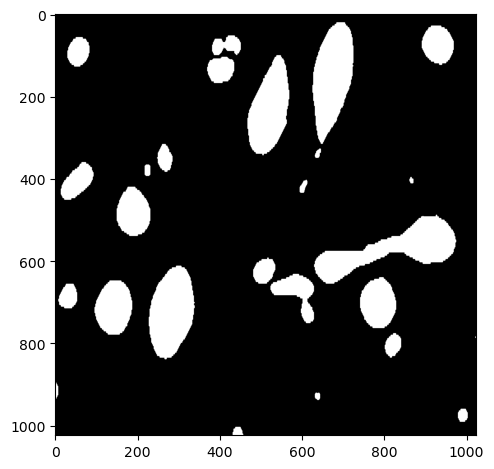

In [ ]:
# slice_id = [50, 100:580, :640]

tick_fontsize = 14

_ = plt.imshow(Rm_raw[50, :1024, :1024].squeeze(), cmap='gray')
#_ = plt.axis("off")
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/Rmito_raw.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(Rm_gt[50, :1024, :1024].squeeze(), cmap='gray')
#_ = plt.axis("off")
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/Rmito_label.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

In [128]:
Rm_ckpt_path = "/g/kreshuk/talks/segmentation_ModelSelection/experiments/Rmito/BatchNorm/Rm_model4/best_checkpoint.pytorch"
model_cfg = {
    "name": "UNet2D",
    "in_channels": 1,
    "out_channels": 1,
    "layer_order": "bcr",
    "f_maps": 32,
    "final_sigmoid": True,
    "feature_return": False,
    "is_segmentation": True,
    "feature_perturbation": None,
}
Rm_model = get_model(model_cfg)
load_checkpoint(Rm_ckpt_path, Rm_model)
Rm_model = Rm_model.cuda()

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [129]:
E_input = Normalize()(E_raw[None, None, 60])
E_input = torch.from_numpy(E_input).cuda()



In [130]:
Rm_model.eval()
with torch.no_grad():
    #E_input = torch.from_numpy(Hm_raw[None, None, 50, :1024, :1024]).float().cuda()
    RmtoE_pred = Rm_model(E_input).cpu().numpy()
print(RmtoE_pred.shape)

(1, 1, 480, 640)


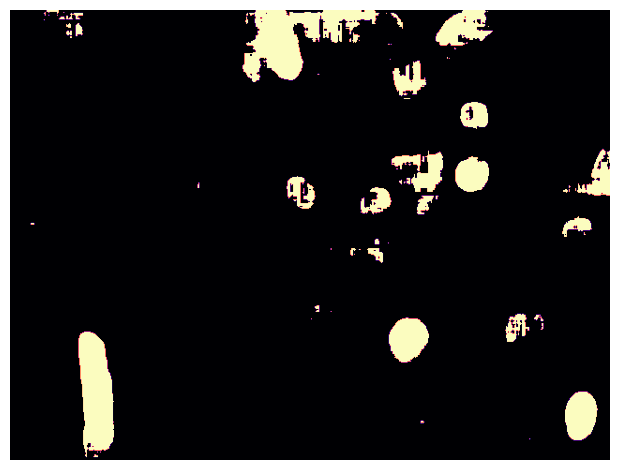

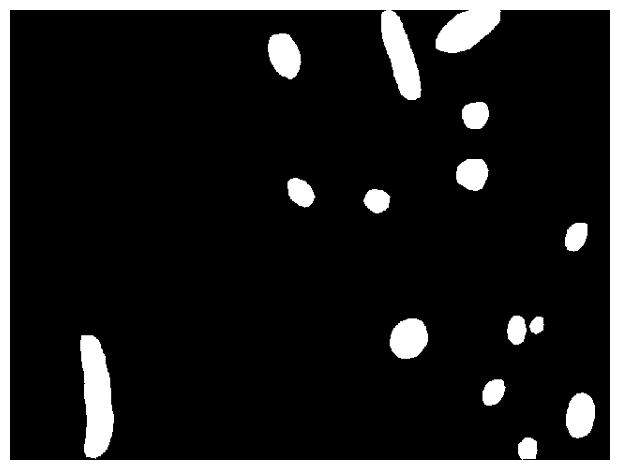

In [133]:
RmtoE_pred_th = RmtoE_pred > 0.5
RmtoE_f1 = F1Score(threshold=0.5)(torch.from_numpy(E_gt[60]).unsqueeze(0), torch.from_numpy(RmtoE_pred_th).unsqueeze(0))
_ = plt.imshow(RmtoE_pred_th.squeeze(), cmap='magma')
_ = plt.axis("off")
#plt.title(f"Rmito to EPFL (F1-score = {RmtoE_f1:.2f})")
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/raw_data/RmtoE_pred.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(E_gt[60].squeeze(), cmap='gray')
_ = plt.axis("off")
plt.tight_layout()
# plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/EPFL_label.png", bbox_inches="tight", pad_inches=0)
plt.show()

# VNC

In [142]:
V_raw_data_path = "/g/kreshuk/talks/data/VNC/resized_pixels/test_converted.h5"

In [144]:
V_raw = load_h5(V_raw_data_path, "raw")
V_gt = load_h5(V_raw_data_path, "labels")
print(V_raw.shape)

(3, 589, 589)


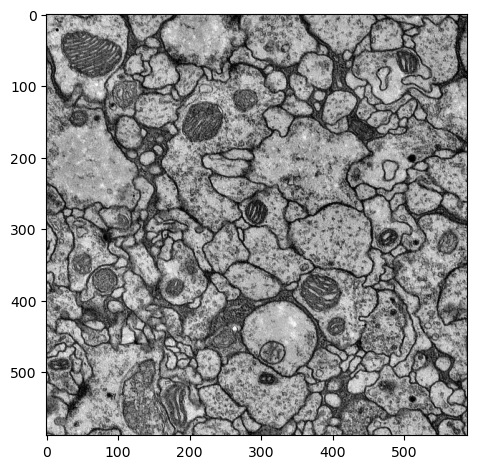

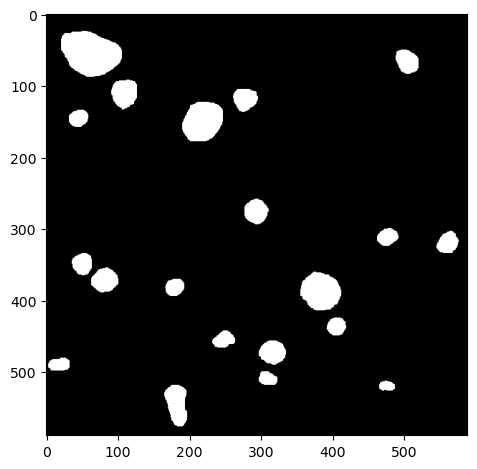

In [ ]:
# slice_id = [50, 100:580, :640]

tick_fontsize = 14

_ = plt.imshow(V_raw[2].squeeze(), cmap='gray')
#_ = plt.axis("off")
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/VNC_raw.png", bbox_inches="tight", pad_inches=0)
plt.show()

_ = plt.imshow(V_gt[2].squeeze(), cmap='gray')
#_ = plt.axis("off")
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/data_examples/VNC_label.png", bbox_inches="tight", pad_inches=0)
plt.show()

In [104]:
V_ckpt_path = "/g/kreshuk/talks/segmentation_ModelSelection/experiments/VNC/BatchNorm/V_model2/best_checkpoint.pytorch"
model_cfg = {
    "name": "UNet2D",
    "in_channels": 1,
    "out_channels": 1,
    "layer_order": "bcr",
    "f_maps": 32,
    "final_sigmoid": True,
    "feature_return": False,
    "is_segmentation": True,
    "feature_perturbation": None,
}
V_model = get_model(model_cfg)
load_checkpoint(V_ckpt_path, V_model)
V_model = V_model.cuda()

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [105]:
E_input = Normalize()(E_raw[None, None, 60])
E_input = torch.from_numpy(E_input).cuda()


In [106]:
V_model.eval()
with torch.no_grad():
    #E_input = torch.from_numpy(Hm_raw[None, None, 50, :1024, :1024]).float().cuda()
    VtoE_pred = V_model(E_input).cpu().numpy()
print(VtoE_pred.shape)

(1, 1, 480, 640)


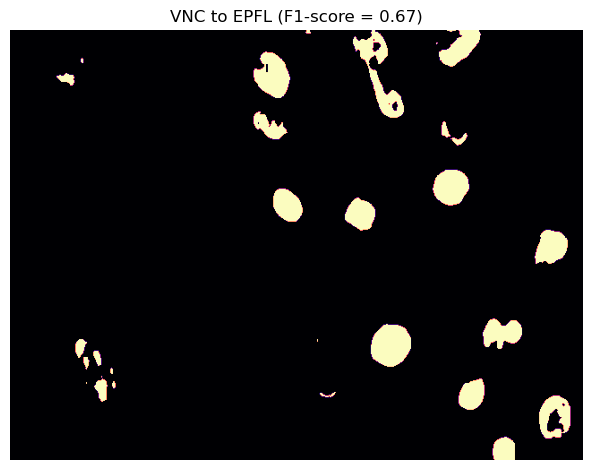

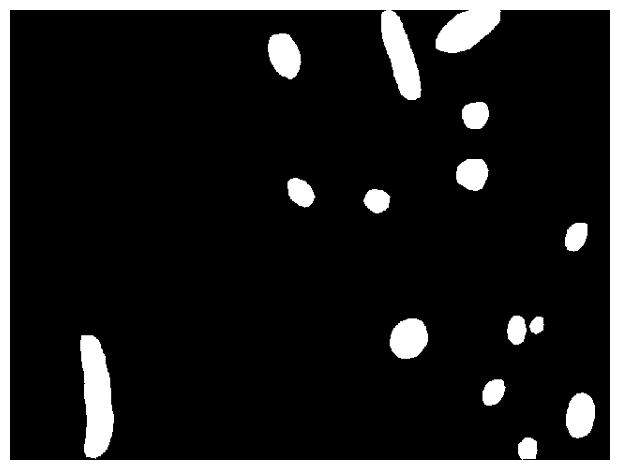

In [107]:
id =60
VtoE_pred_th = VtoE_pred > 0.5
VtoE_f1 = F1Score(threshold=0.5)(torch.from_numpy(E_gt[id]).unsqueeze(0), torch.from_numpy(VtoE_pred_th).unsqueeze(0))
_ = plt.imshow(VtoE_pred_th.squeeze(), cmap='magma')
_ = plt.axis("off")
plt.title(f"VNC to EPFL (F1-score = {VtoE_f1:.2f})")
plt.tight_layout()
# plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/EPFL_raw.png", bbox_inches="tight", pad_inches=0)
plt.show()

_ = plt.imshow(E_gt[id].squeeze(), cmap='gray')
_ = plt.axis("off")
plt.tight_layout()
# plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures/EPFL_label.png", bbox_inches="tight", pad_inches=0)
plt.show()